In [41]:
import numpy as np
import pickle
from copy import deepcopy
import matplotlib.pyplot as plt
import pandas as pd
import os

In [42]:
class SIRAugmenter:
    def __init__(self, param_noise=0.013, comp_noise=0.01,
                 n_param_aug=2, n_comp_aug=1):
        self.param_noise = param_noise
        self.comp_noise  = comp_noise
        self.n_param_aug = n_param_aug
        self.n_comp_aug  = n_comp_aug

    # This is the method your code expects
    def augment_simulation(self, sim):
        sims = [sim]
        for _ in range(self.n_param_aug):
            sims.append(self.augment_params(sim))
        for _ in range(self.n_comp_aug):
            sims.append(self.augment_compartments(sim))
        return sims

    def augment_params(self, sim):
        sim_new = deepcopy(sim)
        params = sim_new['params']
        for k in ['tau', 'gamma', 'rho']:
            params[k] *= 1 + np.random.normal(0, self.param_noise)
        return sim_new

    def augment_compartments(self, sim):
        sim_new = deepcopy(sim)
        out = sim_new['output']
        S, I, R = np.array(out['S']), np.array(out['I']), np.array(out['R'])
        S2 = np.maximum(S * (1 + np.random.normal(0, self.comp_noise, S.shape)), 0)
        I2 = np.maximum(I * (1 + np.random.normal(0, self.comp_noise, I.shape)), 0)
        R2 = np.maximum(R * (1 + np.random.normal(0, self.comp_noise, R.shape)), 0)
        N = S[0] + I[0] + R[0]
        factor = N / (S2 + I2 + R2 + 1e-8)
        sim_new['output'] = {'t': out['t'],
                             'S': (S2 * factor).tolist(),
                             'I': (I2 * factor).tolist(),
                             'R': (R2 * factor).tolist()}
        return sim_new


In [43]:



def augment_compartments(self, sim):
        sim_new = deepcopy(sim)
        out = sim["output"]

        # ensure arrays
        S, I, R = np.array(out["S"]), np.array(out["I"]), np.array(out["R"])

        S2 = S * (1 + np.random.normal(0, self.comp_noise, S.shape))
        I2 = I * (1 + np.random.normal(0, self.comp_noise, I.shape))
        R2 = R * (1 + np.random.normal(0, self.comp_noise, R.shape))

        S2 = np.maximum(S2, 0)
        I2 = np.maximum(I2, 0)
        R2 = np.maximum(R2, 0)

        N = S[0] + I[0] + R[0]
        total = S2 + I2 + R2
        factor = N / (total + 1e-8)

        S2 *= factor
        I2 *= factor
        R2 *= factor

        sim_new["output"] = {
            "t": out["t"],
            "S": S2.tolist(),
            "I": I2.tolist(),
            "R": R2.tolist()
        }

        return sim_new

# Apply augmentation


def augment_simulation(self, sim):

        sims = [deepcopy(sim)]

        for _ in range(self.n_param_aug):
            sims.append(self.augment_params(sim))

        for _ in range(self.n_comp_aug):
            sims.append(self.augment_compartments(sim))

        return sims


In [44]:
def augment_train_split(split_data, augmenter):

    augmented = deepcopy(split_data)

    original = split_data["train"]["simulations"]
    new_sims = []

    for sim in original:
        new_sims.extend(augmenter.augment_simulation(sim))

    augmented["train"]["simulations"] = new_sims

    return augmented


# Run augmentation

if __name__ == "__main__":

    with open("epidemic_data_age_adaptive_sobol_split.pkl", "rb") as f:
        data = pickle.load(f)

    augmenter = SIRAugmenter()

    augmented = augment_train_split(data, augmenter)

    with open("epidemic_data_age_adaptive_sobol_split_augmented.pkl", "wb") as f:
        pickle.dump(augmented, f)

    print("Augmentation complete.")

Augmentation complete.


In [45]:
import os
print(os.getcwd())

c:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\MLP3


In [46]:
import pickle
import pandas as pd

# Load augmented data
with open("epidemic_data_age_adaptive_sobol_split_augmented.pkl", "rb") as f:
    split_data = pickle.load(f)

# Function to export CSV
def export_params_with_R0(split_data, csv_path, split_name="train"):
    sims = split_data[split_name]['simulations']
    rows = []
    for sim in sims:
        tau   = sim['params']['tau']
        gamma = sim['params']['gamma']
        rho   = sim['params']['rho']
        R0    = (tau / gamma) * 27.26
        rows.append({'tau': tau, 'gamma': gamma, 'rho': rho, 'R0': R0})

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f" CSV saved to: {csv_path}, shape={df.shape}")
    return df

# Call function
csv_file = "epidemic_data_age_adaptive_sobol_split_augmented.csv"
df_exported = export_params_with_R0(split_data, csv_file, split_name="train")

# Quick check
print(df_exported.head())

 CSV saved to: epidemic_data_age_adaptive_sobol_split_augmented.csv, shape=(6992, 4)
        tau     gamma       rho        R0
0  0.006993  0.389814  0.003478  0.489032
1  0.006965  0.392116  0.003500  0.484185
2  0.006974  0.389929  0.003529  0.487565
3  0.006993  0.389814  0.003478  0.489032
4  0.010482  0.445876  0.003613  0.640873


In [47]:

augmented_data=pd.read_csv('epidemic_data_age_adaptive_sobol_split_augmented.csv')

print(augmented_data.columns)
print(len(augmented_data))
print(augmented_data.isnull().sum()) # no missing values
augmented_data.describe(include='all')

Index(['tau', 'gamma', 'rho', 'R0'], dtype='object')
6992
tau      0
gamma    0
rho      0
R0       0
dtype: int64


,tau,gamma,rho,R0
count,6992.000000,6992.000000,6992.000000,6992.000000
mean,0.012189,0.337426,0.005439,0.988007
std,0.005565,0.110892,0.002608,0.294454
min,0.002385,0.069349,0.000997,0.145966
25%,0.007864,0.254583,0.003251,0.786036
50%,0.011716,0.353926,0.005420,0.985675
75%,0.016131,0.433646,0.007703,1.189352
max,0.031896,0.515594,0.010214,1.944429


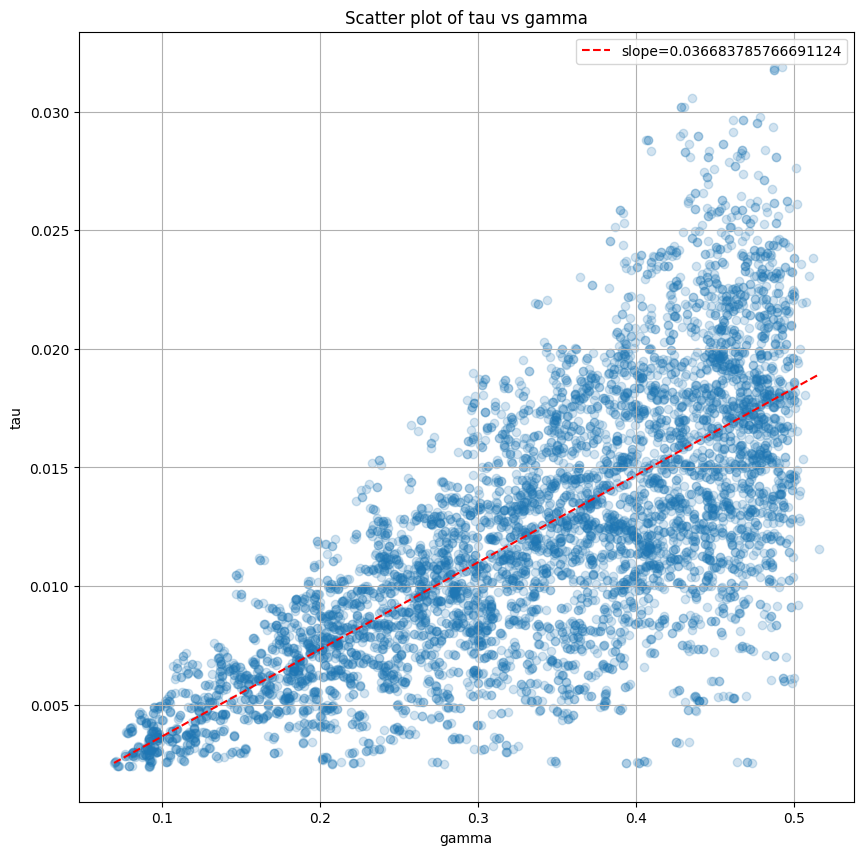

In [48]:
#Plotting
import matplotlib.pyplot as plt



slope=1/27.26
plt.figure(figsize=(10,10))
plt.scatter(augmented_data['gamma'], augmented_data['tau'], alpha=0.2)

x_vals = np.linspace(augmented_data['gamma'].min(), augmented_data['gamma'].max(), 100)
y_vals = slope * x_vals

plt.plot(x_vals, y_vals, color='red', linestyle='--', label=f'slope={slope}')

plt.xlabel('gamma')
plt.ylabel('tau')
plt.title('Scatter plot of tau vs gamma')
plt.legend()
plt.grid(True)
plt.show()
    

